In [62]:
# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

In [63]:
%pip install xgboost imbalanced-learn

In [64]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score,
                             ConfusionMatrixDisplay)
import xgboost as xgb
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("✓ All libraries loaded")
print(f"  pandas: {pd.__version__}")
print(f"  xgboost: {xgb.__version__}")

✓ All libraries loaded
  pandas: 2.1.4
  xgboost: 3.2.0


## **Load dataset from Google Drive**

In [65]:
#Loading the dataset and checking shape, data types, summary statistics, class
#balance, zero-amount transactions, and feature variance/skewness.
#df = pd.read_csv('/content/drive/MyDrive/dissertation/creditcard.csv')
df = pd.read_csv('creditcard.csv')

print("DATASET OVERVIEW")
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

DATASET OVERVIEW

Shape: 284,807 rows × 31 columns
Missing values: 0

Fraud percentage: 0.1727%


In [66]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [67]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [68]:
df[['Time','Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [69]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [70]:
print('Zero-amount transactions:', (df['Amount'] == 0).sum())
print('Zero-amount that are fraud:', ((df['Amount']==0) & (df['Class']==1)).sum())

Zero-amount transactions: 1825
Zero-amount that are fraud: 27


In [71]:
#Check that no feature is useless (barely changes - std) or unusually shaped (skeweness)
v_cols = [c for c in df.columns if c.startswith('V')]
print(df[v_cols].std().sort_values().head(5))
print(df[v_cols].skew().abs().sort_values(ascending=False).head(5))

V28    0.330083
V27    0.403632
V26    0.482227
V25    0.521278
V24    0.605647
dtype: float64
V28    11.192091
V8      8.521944
V23     5.875140
V2      4.624866
V17     3.844914
dtype: float64


### **Class imbalance**

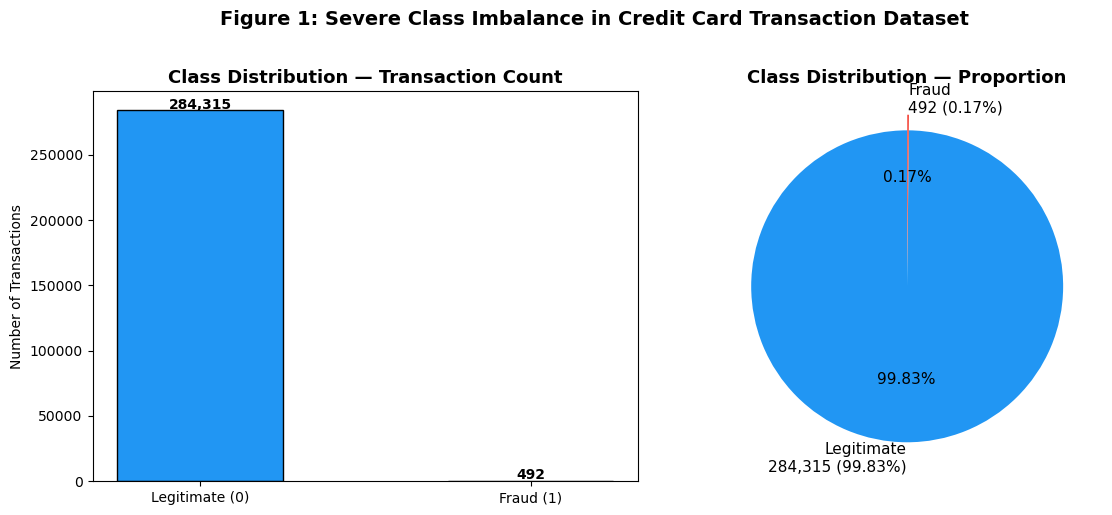

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Transaction Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values,
            labels=[f'Legitimate\n{class_counts[0]:,} (99.83%)',
                    f'Fraud\n{class_counts[1]:,} (0.17%)'],
            colors=['#2196F3', '#F44336'], explode=(0, 0.1),
            autopct='%1.2f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Severe Class Imbalance in Credit Card Transaction Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/dissertation/fig1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

### **Transaction Amount Distribution**

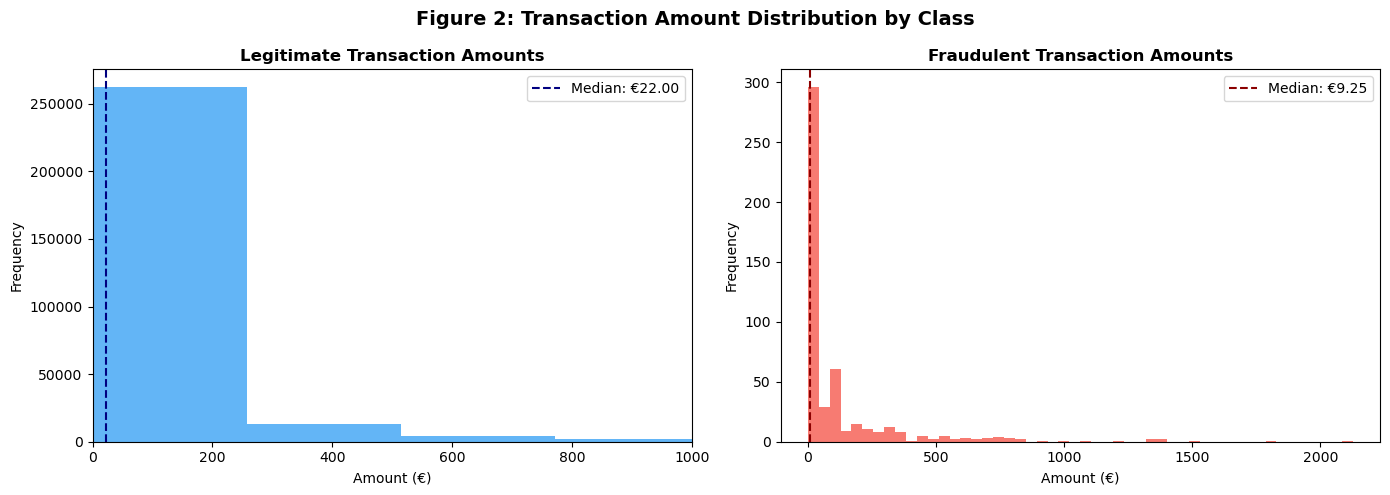

Amount Statistics:
Legitimate — Mean: €88.29, Median: €22.00, Max: €25,691.16
Fraud      — Mean: €122.21, Median: €9.25, Max: €2,125.87


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=100, color='#2196F3', alpha=0.7, edgecolor='none')
axes[0].set_title('Legitimate Transaction Amounts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1000)
axes[0].axvline(df[df['Class']==0]['Amount'].median(), color='navy', linestyle='--',
                label=f"Median: €{df[df['Class']==0]['Amount'].median():.2f}")
axes[0].legend()

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#F44336', alpha=0.7, edgecolor='none')
axes[1].set_title('Fraudulent Transaction Amounts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df[df['Class']==1]['Amount'].median(), color='darkred', linestyle='--',
                label=f"Median: €{df[df['Class']==1]['Amount'].median():.2f}")
axes[1].legend()

plt.suptitle('Figure 2: Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/dissertation/fig2_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("Amount Statistics:")
print(f"Legitimate — Mean: €{df[df['Class']==0]['Amount'].mean():.2f}, "
      f"Median: €{df[df['Class']==0]['Amount'].median():.2f}, "
      f"Max: €{df[df['Class']==0]['Amount'].max():,.2f}")
print(f"Fraud      — Mean: €{df[df['Class']==1]['Amount'].mean():.2f}, "
      f"Median: €{df[df['Class']==1]['Amount'].median():.2f}, "
      f"Max: €{df[df['Class']==1]['Amount'].max():,.2f}")

### **Transaction Time Patterns**

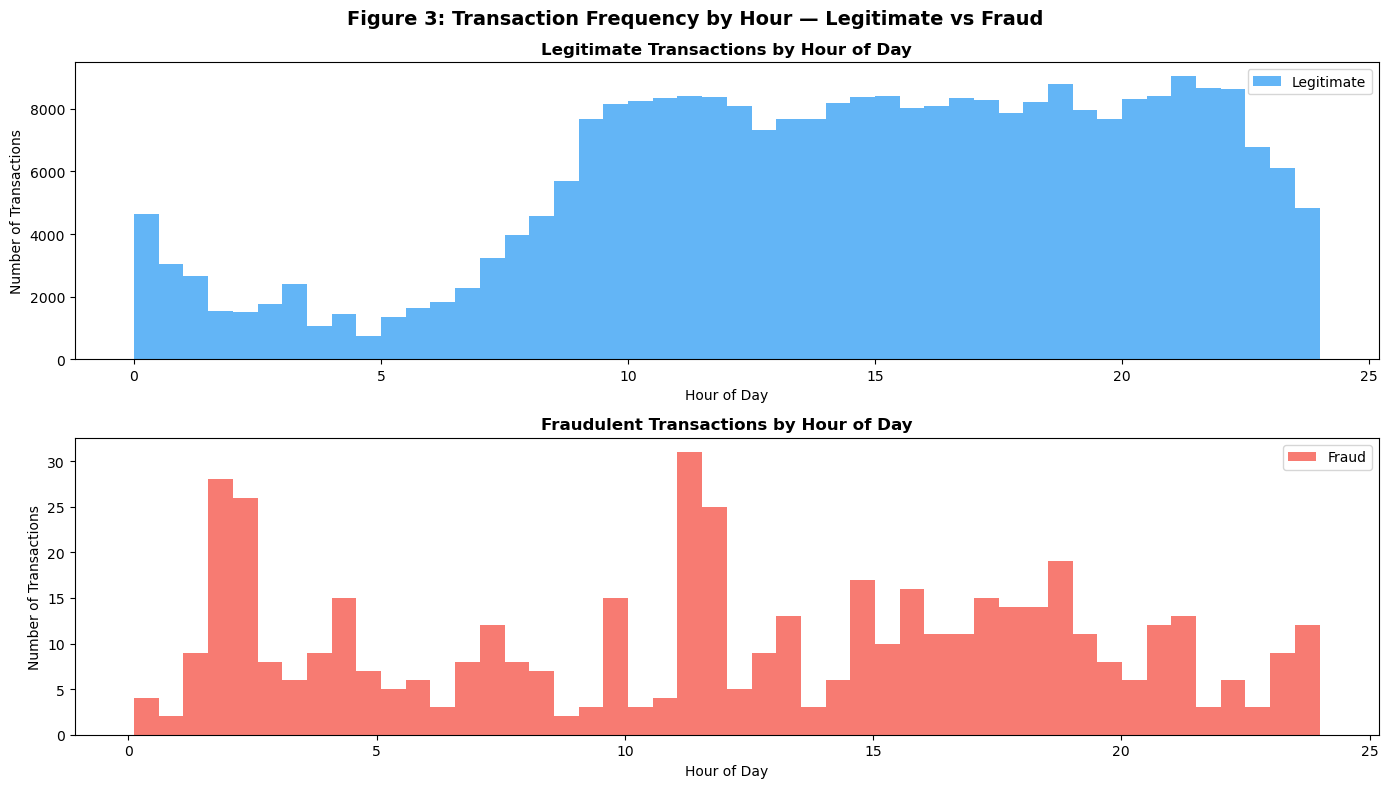

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
df['Hour'] = (df['Time'] / 3600) % 24

axes[0].hist(df[df['Class']==0]['Hour'], bins=48, color='#2196F3', alpha=0.7, label='Legitimate')
axes[0].set_title('Legitimate Transactions by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()

axes[1].hist(df[df['Class']==1]['Hour'], bins=48, color='#F44336', alpha=0.7, label='Fraud')
axes[1].set_title('Fraudulent Transactions by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Number of Transactions')
axes[1].legend()

plt.suptitle('Figure 3: Transaction Frequency by Hour — Legitimate vs Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig3_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **Correlation Heatmap**

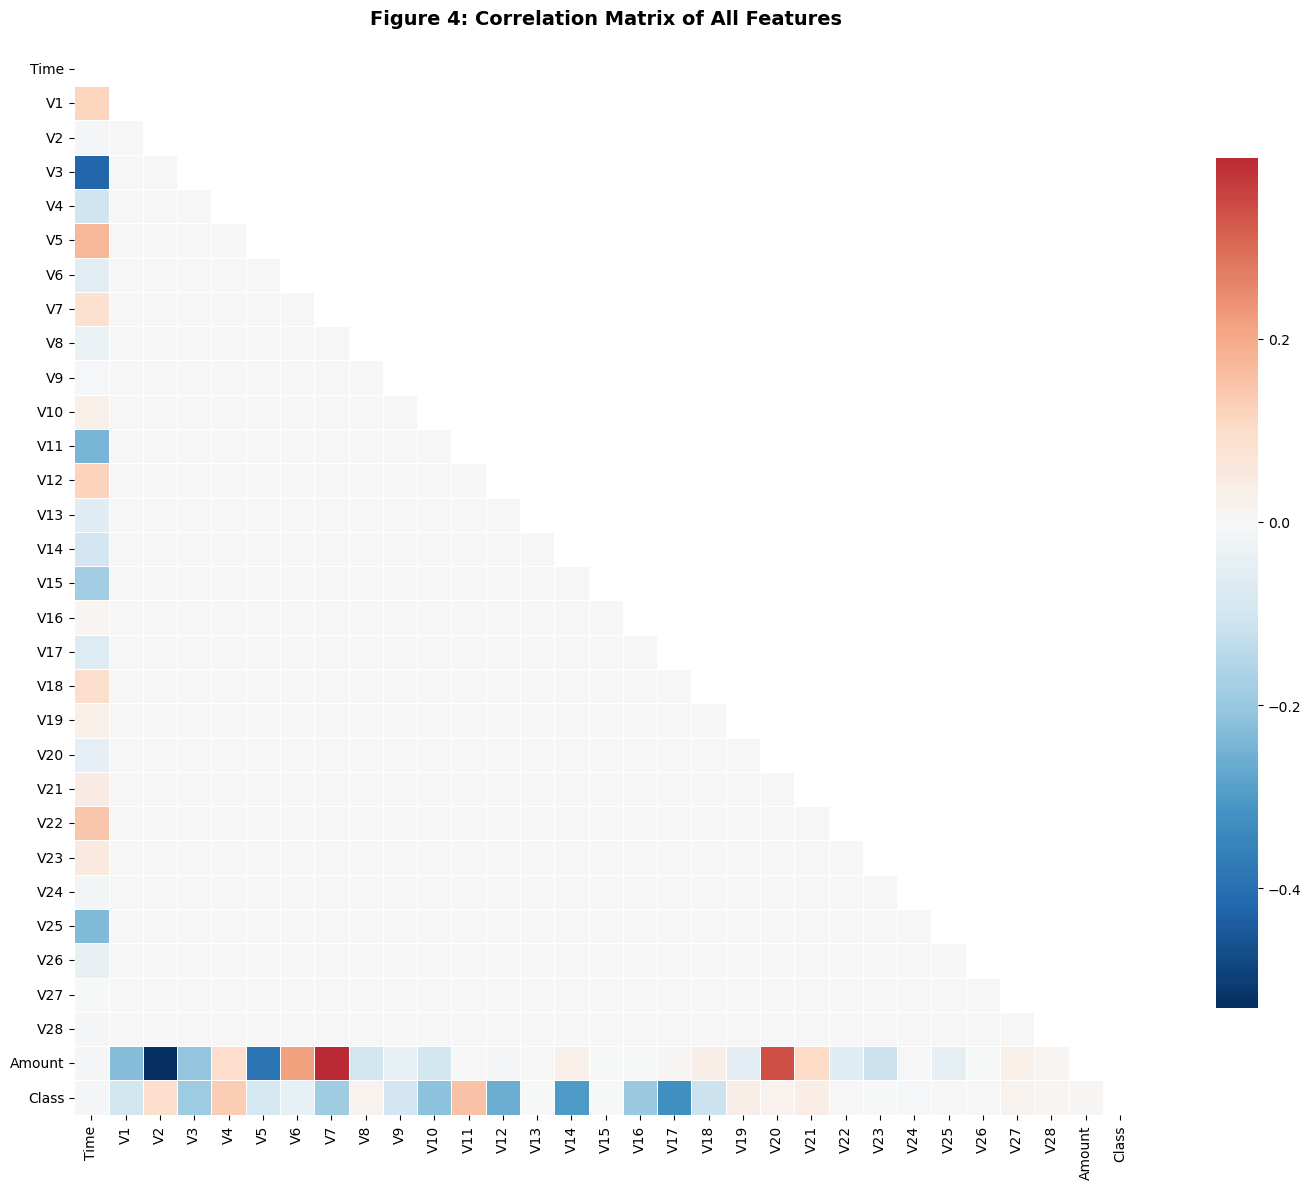

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [75]:
# Visualizing the correlation of every feature against Class and against each other
plt.figure(figsize=(16, 12))
corr_matrix = df.drop('Hour', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, annot=False)
plt.title('Figure 4: Correlation Matrix of All Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr_matrix['Class'].abs().sort_values(ascending=False)[1:11])

### **Distribution of Top 6 Fraud-Correlated Features (V17, V14, V12, V10, V16, V3) by Class**

Top 6 features used: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


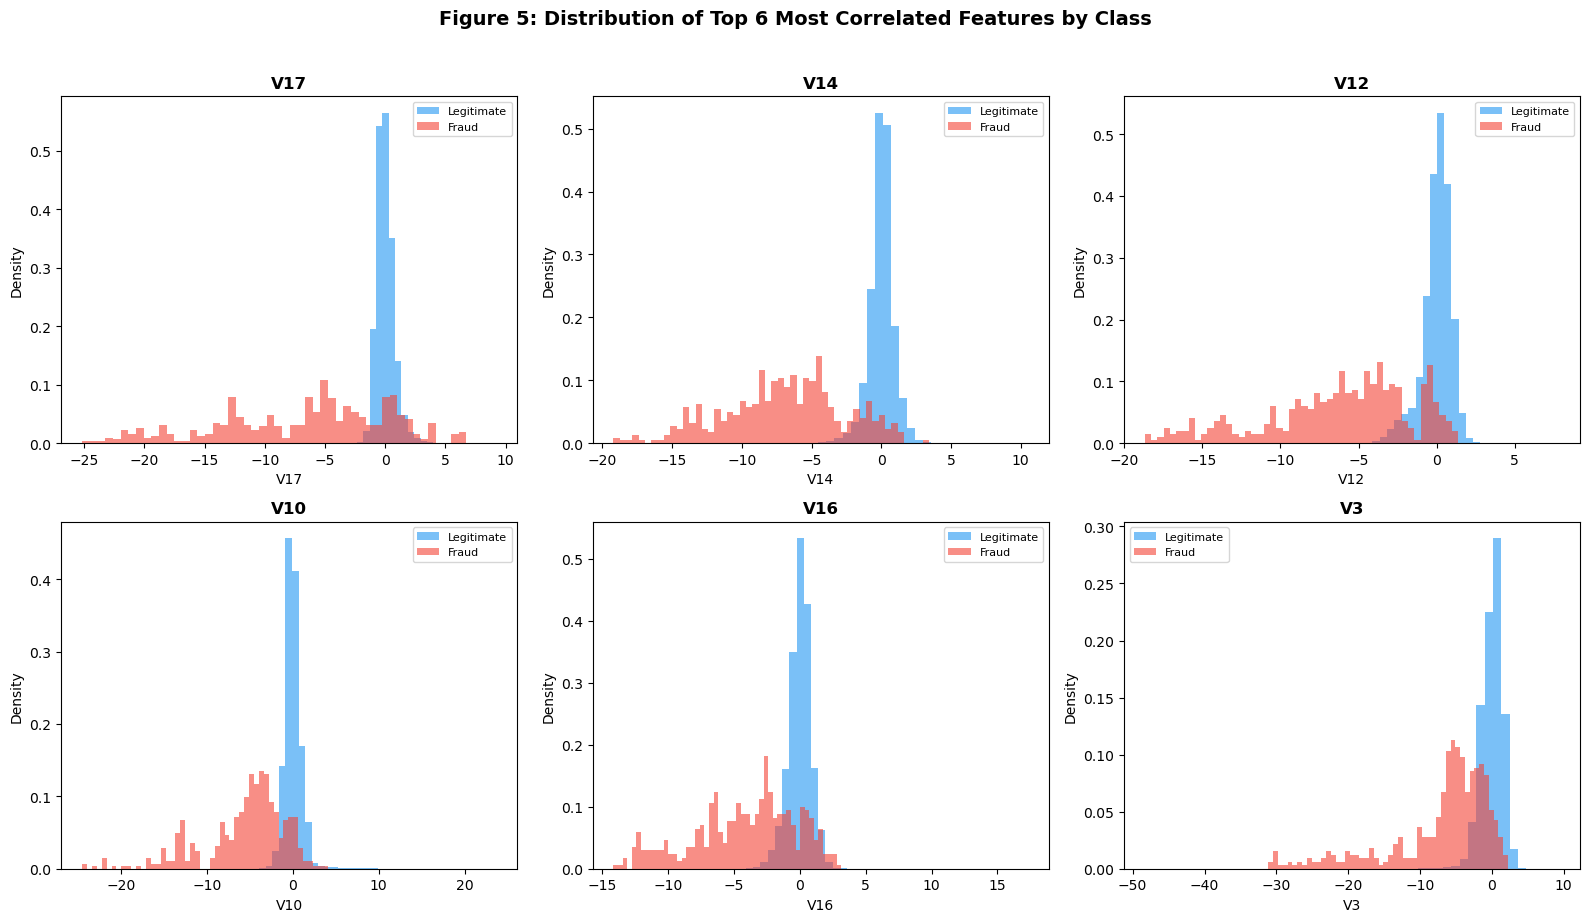

In [76]:
corr_matrix_full = df.drop(columns=['Class']).corrwith(df['Class'])
top6 = corr_matrix_full.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 features used:", top6)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top6):
    axes[i].hist(df[df['Class']==0][col], bins=50, color='#2196F3', alpha=0.6,
                 density=True, label='Legitimate')
    axes[i].hist(df[df['Class']==1][col], bins=50, color='#F44336', alpha=0.6,
                 density=True, label='Fraud')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 5: Distribution of Top 6 Most Correlated Features by Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig5_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

## **Pairplot of Top 4 Correlated Features**

Top 4 features used in pairplot: ['V17', 'V14', 'V12', 'V10']


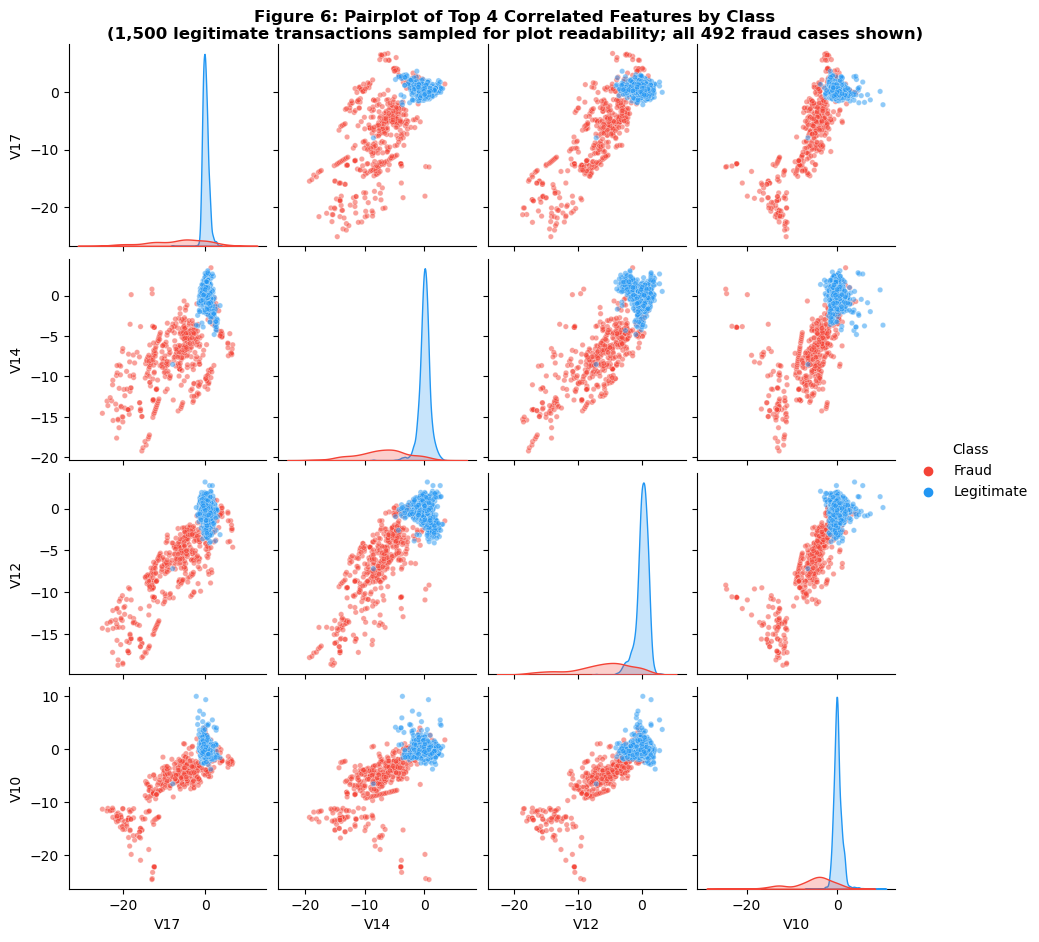

In [77]:
corr_full = df.drop(columns=['Class']).corrwith(df['Class'])
top4 = corr_full.abs().sort_values(ascending=False).head(4).index.tolist()
print(f"Top 4 features used in pairplot: {top4}")

# Undersample legitimate class purely for plot readability - 492 fraud points would be
# invisible against 284,315 legitimate points on a scatterplot.
np.random.seed(42)
fraud = df[df['Class'] == 1]
legit_sample = df[df['Class'] == 0].sample(n=1500, random_state=42)
plot_df = pd.concat([fraud, legit_sample])[top4 + ['Class']].copy()
plot_df['Class'] = plot_df['Class'].map({0: 'Legitimate', 1: 'Fraud'})

g = sns.pairplot(plot_df, hue='Class', palette={'Legitimate': '#2196F3', 'Fraud': '#F44336'},
                  plot_kws={'alpha': 0.5, 's': 15}, diag_kind='kde', height=2.3)
g.fig.suptitle('Figure 6: Pairplot of Top 4 Correlated Features by Class\n'
               '(1,500 legitimate transactions sampled for plot readability; all 492 fraud cases shown)',
               fontsize=12, fontweight='bold', y=1.02)
# g.savefig('/content/drive/MyDrive/dissertation/fig6_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## **Data Cleaning**

Checking for duplicate rows and documenting the decision to retain them as plausible genuine repeat transactions

In [78]:
# Double check check
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate fraud rows:', df[df.duplicated()]['Class'].sum())
print('Decision -> RETAINED as plausible genuine repeat transactions.')

Duplicate rows: 1081
Duplicate fraud rows: 19
Decision -> RETAINED as plausible genuine repeat transactions.


In [79]:
# Removing EDA-only 'Hour' Feature
df = df.drop('Hour', axis=1)

## **Preprocessing**

Scaling `Time` and `Amount`, then performing the leakage-safe train/test split before any sampling is applied.

In [80]:
scaler = StandardScaler()
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time', 'Amount'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

print(f"Feature set: {X.shape[1]} columns")

Feature set: 30 columns


In [81]:
# Leakage safe split happens before the sampling technique is applied
# The stratyfy=y helps keeping the same 0.17% fraud rate in the train and the test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%  |  Test fraud rate: {y_test.mean()*100:.4f}%")

Train: (227845, 30), Test: (56962, 30)
Train fraud rate: 0.1729%  |  Test fraud rate: 0.1720%


## **Defining the models and sampling functions**

In [82]:
# 4 algorithms compared in the research
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
}

# Applying the chosen sampling startegy to the training data only
# for keeping the results leakage safe, test data is never touched
def get_sampled(X_train, y_train, strategy):
    if strategy == 'None (baseline)':
        return X_train, y_train
    elif strategy == 'Undersampling':
        rus = RandomUnderSampler(random_state=RANDOM_STATE)
        return rus.fit_resample(X_train, y_train)
    elif strategy == 'SMOTE':
        sm = SMOTE(random_state=RANDOM_STATE)
        return sm.fit_resample(X_train, y_train)

## Running the Full 4×3 Model Grid

Training all 4 algorithms under each of the 3 sampling strategies (12 combinations total) and evaluating each against the same untouched test set.

In [83]:
# 4 algorithms x 3 sampling strategies = 12 combinations
# each combination is trained on its own resampled training data
# evaluated against the same imbalanced test set
results = []
roc_data = {}
y_pred_store = {}

for strategy in ['None (baseline)', 'Undersampling', 'SMOTE']:
  # sampling is applied to X_train/y_train only
  #instead, X_test/y_test are not touched for keeping leakage safe
    X_tr_s, y_tr_s = get_sampled(X_train, y_train, strategy)
    print(f"\n Sampling: {strategy} | Train size: {len(y_tr_s):,}, fraud: {y_tr_s.sum()} ({y_tr_s.mean()*100:.2f}%)")

    for model_name, model in models.items():
        t0 = time.time()
        model.fit(X_tr_s, y_tr_s)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]  #probability for fraud
        elapsed = time.time() - t0

        # Computing 4 evaluation metrics against the imbalanced test labels

        prec = precision_score(y_test, y_pred, zero_division=0)  # zero_division=0 for avoiding errors
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_proba)
        acc = accuracy_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel() # list of 4 numbers

        results.append({
            'Model': model_name, 'Sampling': strategy,
            'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1': round(f1, 4),
            'ROC-AUC': round(auc, 4), 'Accuracy': round(acc, 4),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn, 'Time_s': round(elapsed, 2)
        })
        # Storing for figures (ROC curves & confusion matrix)
        roc_data[f"{model_name} ({strategy})"] = roc_curve(y_test, y_proba)
        y_pred_store[f"{model_name} ({strategy})"] = y_pred

        print(f"  {model_name:22s} P={prec:.4f} R={rec:.4f} F1={f1:.4f} AUC={auc:.4f} FN={fn} FP={fp} ({elapsed:.1f}s)")

results_df = pd.DataFrame(results)
# results_df.to_csv('/content/drive/MyDrive/dissertation/results_table.csv', index=False)


 Sampling: None (baseline) | Train size: 227,845, fraud: 394 (0.17%)
  Logistic Regression    P=0.8312 R=0.6531 F1=0.7314 AUC=0.9561 FN=34 FP=13 (1.6s)
  Decision Tree          P=0.7228 R=0.7449 F1=0.7337 AUC=0.8722 FN=25 FP=28 (21.2s)
  Random Forest          P=0.9524 R=0.8163 F1=0.8791 AUC=0.9528 FN=18 FP=4 (59.5s)
  XGBoost                P=0.8667 R=0.7959 F1=0.8298 AUC=0.9390 FN=20 FP=12 (2.3s)

 Sampling: Undersampling | Train size: 788, fraud: 394 (50.00%)
  Logistic Regression    P=0.0385 R=0.9184 F1=0.0739 AUC=0.9759 FN=8 FP=2249 (0.0s)
  Decision Tree          P=0.0159 R=0.9082 F1=0.0312 AUC=0.9056 FN=9 FP=5514 (0.1s)
  Random Forest          P=0.0424 R=0.9184 F1=0.0810 AUC=0.9770 FN=8 FP=2035 (0.4s)
  XGBoost                P=0.0336 R=0.9184 F1=0.0648 AUC=0.9721 FN=8 FP=2588 (0.2s)

 Sampling: SMOTE | Train size: 454,902, fraud: 227451 (50.00%)
  Logistic Regression    P=0.0580 R=0.9184 F1=0.1092 AUC=0.9699 FN=8 FP=1461 (2.7s)
  Decision Tree          P=0.3408 R=0.7755 F1=0.

In [84]:
# Sorting the results table by F1-score to see the best-performing combination
results_df.sort_values('F1', ascending=False).reset_index(drop=True)

,Model,Sampling,Precision,Recall,F1,ROC-AUC,Accuracy,TP,FP,FN,TN,Time_s
0,Random Forest,None (baseline),0.9524,0.8163,0.8791,0.9528,0.9996,80,4,18,56860,59.46
1,XGBoost,None (baseline),0.8667,0.7959,0.8298,0.9390,0.9994,78,12,20,56852,2.27
2,Random Forest,SMOTE,0.8404,0.8061,0.8229,0.9841,0.9994,79,15,19,56849,150.64
3,XGBoost,SMOTE,0.7311,0.8878,0.8018,0.9792,0.9992,87,32,11,56832,6.30
4,Decision Tree,None (baseline),0.7228,0.7449,0.7337,0.8722,0.9991,73,28,25,56836,21.20
5,Logistic Regression,None (baseline),0.8312,0.6531,0.7314,0.9561,0.9992,64,13,34,56851,1.65
6,Decision Tree,SMOTE,0.3408,0.7755,0.4735,0.8865,0.9970,76,147,22,56717,58.19
7,Logistic Regression,SMOTE,0.0580,0.9184,0.1092,0.9699,0.9742,90,1461,8,55403,2.72
8,Random Forest,Undersampling,0.0424,0.9184,0.0810,0.9770,0.9641,90,2035,8,54829,0.44
9,Logistic Regression,Undersampling,0.0385,0.9184,0.0739,0.9759,0.9604,90,2249,8,54615,0.05


### **Precision/Recall/F1 comparison**

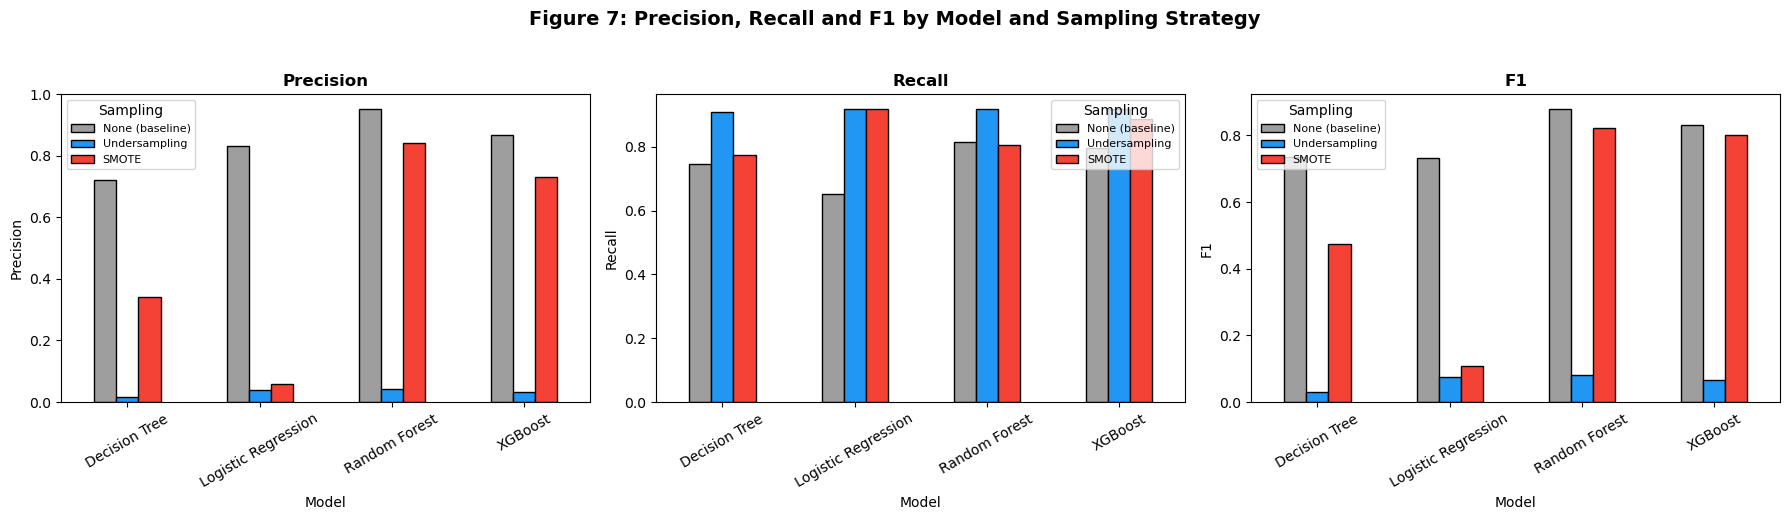

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Precision', 'Recall', 'F1']
for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Model', columns='Sampling', values=metric)
    pivot = pivot[['None (baseline)', 'Undersampling', 'SMOTE']]
    pivot.plot(kind='bar', ax=ax, rot=30, color=['#9E9E9E', '#2196F3', '#F44336'], edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(title='Sampling', fontsize=8)

plt.suptitle('Figure 7: Precision, Recall and F1 by Model and Sampling Strategy',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig7_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### **ROC curves**

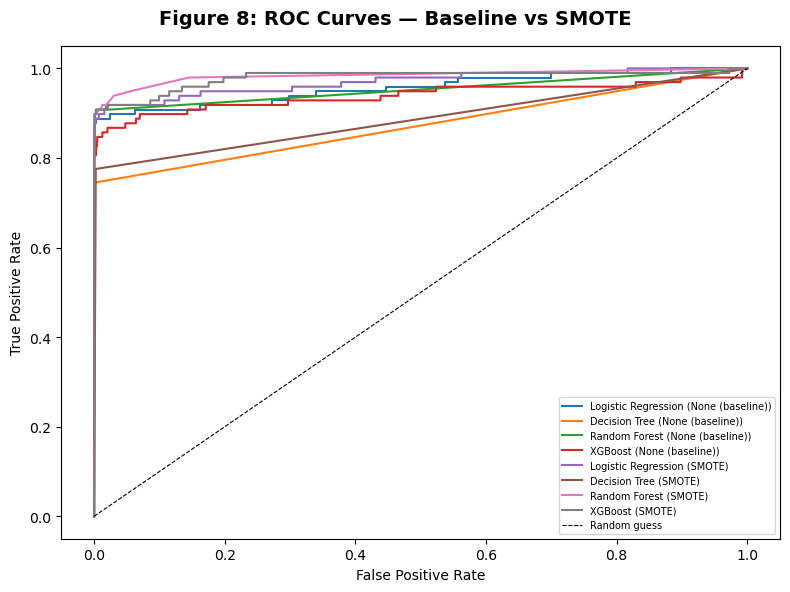

In [86]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
i = 0
for label, (fpr, tpr, _) in roc_data.items():
    if '(None (baseline))' in label or '(SMOTE)' in label:
        ax.plot(fpr, tpr, label=label, linewidth=1.5, color=colors[i % 10])
        i += 1
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Figure 8: ROC Curves — Baseline vs SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### **Confusion matrix for the best model**

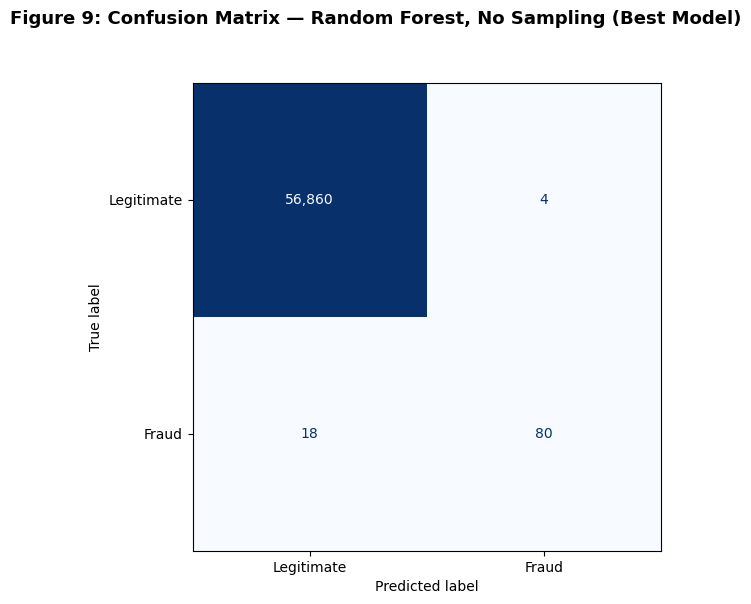

In [87]:
# Random Forest (No Sampling) -> the strongest F1 result
best_key = 'Random Forest (None (baseline))'
cm = confusion_matrix(y_test, y_pred_store[best_key])

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')

plt.suptitle('Figure 9: Confusion Matrix — Random Forest, No Sampling (Best Model)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig9_confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

### **Hyperparameter Tuning - Random Forest and XGBoost**

In [88]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [89]:
# Set up cross-validation startegy
# StratifiedKFold keeps the same fraud percentage as the whole dataset
# splitting the training data in 2, so one can train and then check the performance on the other
cv_strategy = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

In [90]:
# Tune Rndom Forest

rf_param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

t0 = time.time()
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=4,
    scoring='f1',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1 # Print real-time updates
)
rf_search.fit(X_train, y_train)

print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV F1: {rf_search.best_score_:.4f}  ({time.time()-t0:.1f}s)")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best RF CV F1: 0.8466  (340.6s)


In [91]:
# Tune XGBoost

xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

t0 = time.time()
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring='f1',
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB CV F1: {xgb_search.best_score_:.4f}  ({time.time()-t0:.1f}s)")

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best XGB params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
Best XGB CV F1: 0.8415  (46.0s)


In [92]:
# Evaluating both tuned models on the untouched test set

tuning_results = []

for name, search in [('Random Forest (tuned)', rf_search), ('XGBoost (tuned)', xgb_search)]:
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    tuning_results.append({
        'Model': name, 'Best_Params': str(search.best_params_),
        'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1': round(f1, 4),
        'ROC-AUC': round(auc, 4), 'Accuracy': round(acc, 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })
    print(f"{name}: P={prec:.4f} R={rec:.4f} F1={f1:.4f} AUC={auc:.4f} FN={fn} FP={fp}")

tuning_results_df = pd.DataFrame(tuning_results)
# tuning_results_df.to_csv('/content/drive/MyDrive/dissertation/tuning_results.csv', index=False)
tuning_results_df

Random Forest (tuned): P=0.9524 R=0.8163 F1=0.8791 AUC=0.9703 FN=18 FP=4
XGBoost (tuned): P=0.9157 R=0.7755 F1=0.8398 AUC=0.9550 FN=22 FP=7


,Model,Best_Params,Precision,Recall,F1,ROC-AUC,Accuracy,TP,FP,FN,TN
0,Random Forest (tuned),"{'n_estimators': 100, 'min_samples_split': 2, ...",0.9524,0.8163,0.8791,0.9703,0.9996,80,4,18,56860
1,XGBoost (tuned),"{'subsample': 1.0, 'n_estimators': 100, 'max_d...",0.9157,0.7755,0.8398,0.9550,0.9995,76,7,22,56857


## **Figure 10: Tuned vs Untuned Performance Comparison**

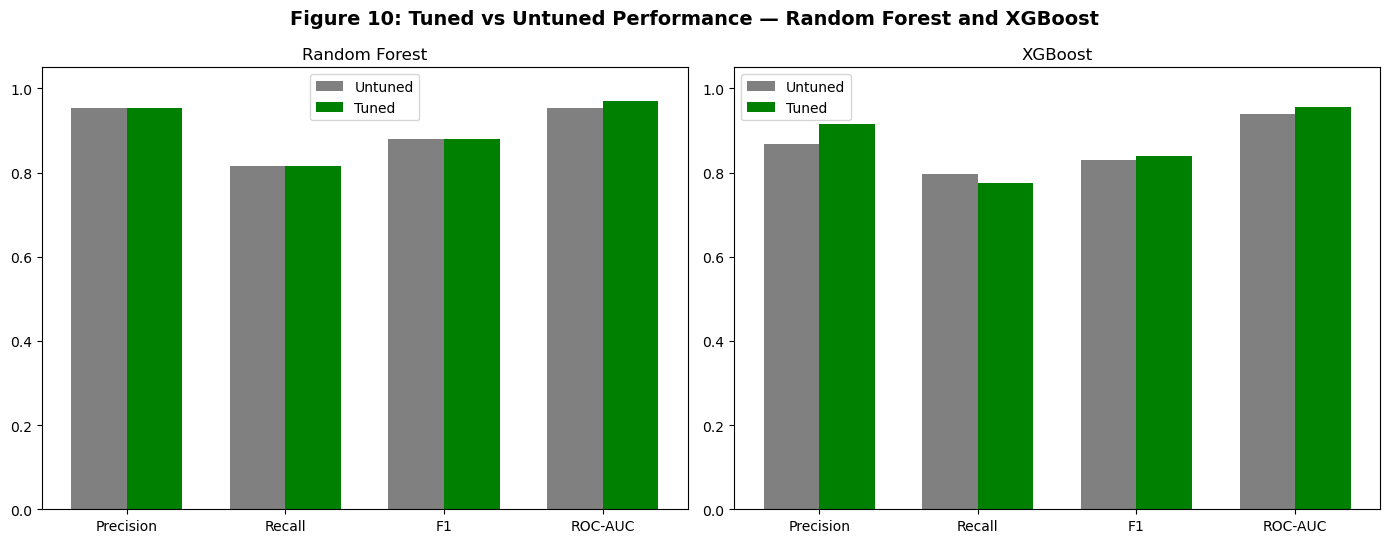

In [93]:
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']

# Pull each row directly
rf_untuned = results_df[(results_df['Model']=='Random Forest') & (results_df['Sampling']=='None (baseline)')][metrics].values[0]
rf_tuned = tuning_results_df[tuning_results_df['Model']=='Random Forest (tuned)'][metrics].values[0]

xgb_untuned = results_df[(results_df['Model']=='XGBoost') & (results_df['Sampling']=='None (baseline)')][metrics].values[0]
xgb_tuned = tuning_results_df[tuning_results_df['Model']=='XGBoost (tuned)'][metrics].values[0]

x = range(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar([i - width/2 for i in x], rf_untuned, width, label='Untuned', color='gray')
axes[0].bar([i + width/2 for i in x], rf_tuned, width, label='Tuned', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Random Forest')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].bar([i - width/2 for i in x], xgb_untuned, width, label='Untuned', color='gray')
axes[1].bar([i + width/2 for i in x], xgb_tuned, width, label='Tuned', color='green')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('XGBoost')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('Figure 10: Tuned vs Untuned Performance — Random Forest and XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig10_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Retrain Baseline Random Forest for Detailed Diagnostics

In [94]:
# Re-fitting a standalone Random Forest baseline model so it can be
# used directly for the diagnostic plots (Figures 11-13)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)  # X_train, y_train are the baseline, unsampled training data

RandomForestClassifier(n_jobs=-1, random_state=42)

## **Figure 11: Precision-Recall Curve**

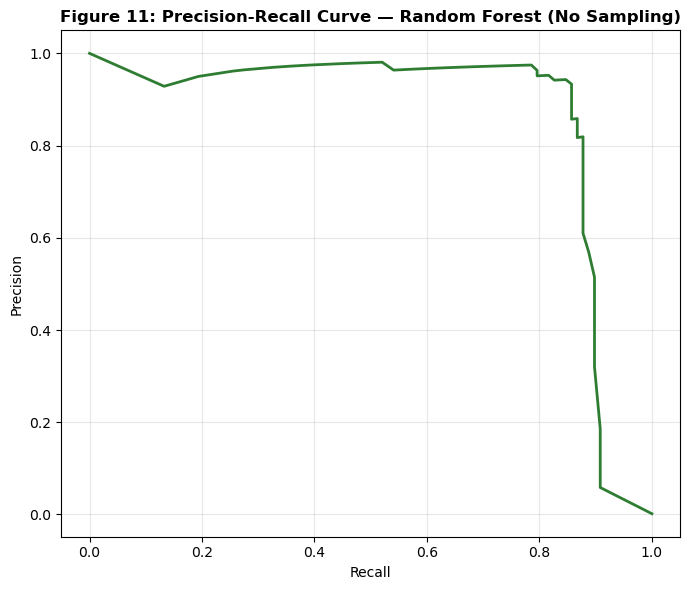

In [95]:
from sklearn.metrics import precision_recall_curve

y_proba = rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='#2E7D32', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Figure 11: Precision-Recall Curve — Random Forest (No Sampling)', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig11_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## **Figure 12: Top 15 Feature Importance**

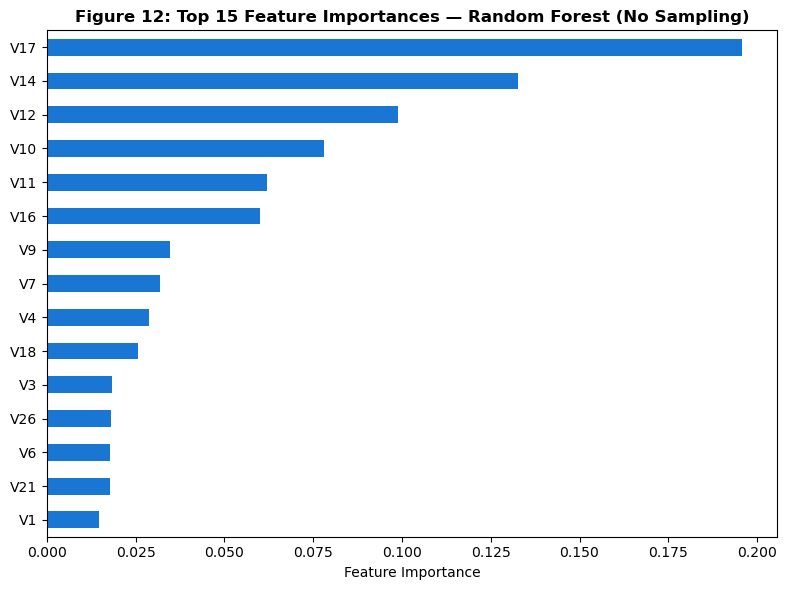

In [96]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.sort_values().plot(kind='barh', color='#1976D2')
plt.xlabel('Feature Importance')
plt.title('Figure 12: Top 15 Feature Importances — Random Forest (No Sampling)', fontweight='bold')
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## **Figure 13: Precision-Recall Trade-off vs Classification Threshold**

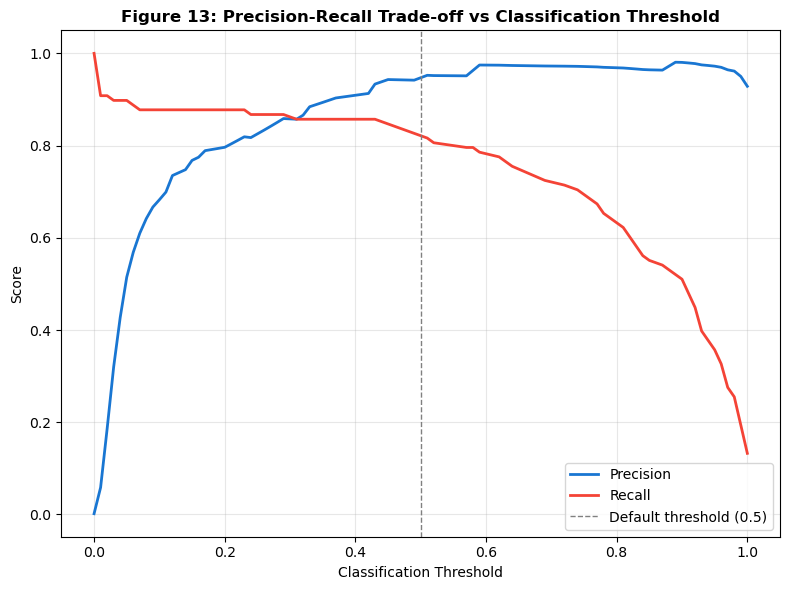

In [97]:
plt.figure(figsize=(8, 6))
# precision[:-1] / recall[:-1]  -> taking the precision/recall list but dropping its last entry
# for matching the lenghts before plotting
plt.plot(thresholds, precision[:-1], label='Precision', color='#1976D2', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', color='#F44336', linewidth=2)
# vertical ref. line at standard 0.5 cutoff point
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Figure 13: Precision-Recall Trade-off vs Classification Threshold', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/dissertation/fig13_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()